In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(
    "spam.csv",
    encoding="latin-1"
)

df = df[["v1","v2"]]

df.columns = [
    "label",
    "message"
]

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [3]:
print("Total Samples:", len(df))

print("\nClass Distribution:\n")

print(
    df["label"].value_counts()
)

Total Samples: 5572

Class Distribution:

label
ham     4825
spam     747
Name: count, dtype: int64


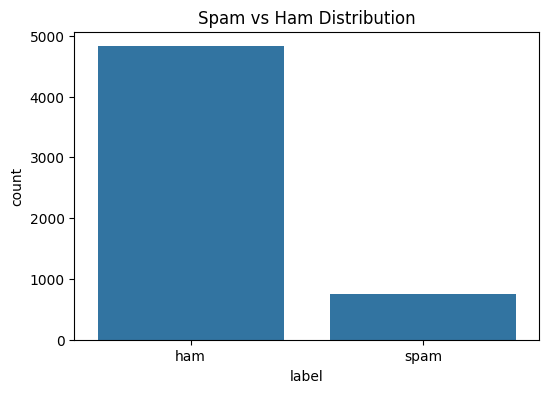

In [4]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="label"
)

plt.title(
    "Spam vs Ham Distribution"
)

plt.show()

In [5]:
df["label"] = df["label"].map({
    "ham":0,
    "spam":1
})

df.head()

,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    df["message"],
    df["label"],
    test_size=0.2,
    random_state=42,
    stratify=df["label"]
)

In [7]:
vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=5000
)

X_train_tfidf = vectorizer.fit_transform(
    X_train
)

X_test_tfidf = vectorizer.transform(
    X_test
)

print(
    "Train Shape:",
    X_train_tfidf.shape
)

Train Shape: (4457, 5000)


In [8]:
model = MultinomialNB()

model.fit(
    X_train_tfidf,
    y_train
)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [9]:
y_pred = model.predict(
    X_test_tfidf
    
)

In [10]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Accuracy : 0.9722
Precision: 0.9917
Recall   : 0.7987
F1 Score : 0.8848


In [11]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Ham",
            "Spam"
        ]
    )
)

              precision    recall  f1-score   support

         Ham       0.97      1.00      0.98       966
        Spam       0.99      0.80      0.88       149

    accuracy                           0.97      1115
   macro avg       0.98      0.90      0.93      1115
weighted avg       0.97      0.97      0.97      1115

